# Maps
conda activate flovopy_pygmt

In [1]:
from pathlib import Path
from typing import Optional, Union

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx


def _load_table(data, sheet_name=None):
    """
    Load a table from a DataFrame, CSV, or Excel file.
    """
    if isinstance(data, pd.DataFrame):
        return data.copy()

    path = str(data).lower()
    if path.endswith(".csv"):
        return pd.read_csv(data)
    if path.endswith((".xls", ".xlsx", ".xlsm")):
        if path.endswith(".xls"):
            return pd.read_excel(data, sheet_name=sheet_name, engine="xlrd")
        return pd.read_excel(data, sheet_name=sheet_name)

    raise ValueError("Unsupported input. Use DataFrame, CSV, XLS, XLSX, or XLSM.")


def _group_nearby_points_rectangular(
    gdf3857: gpd.GeoDataFrame,
    *,
    thresh_x: float,
    thresh_y: float,
    grouped_name_mode: str = "join",
    max_joined_names: int = 4,
    common_prefix_min_lengths: tuple[int, ...] = (4, 3),
) -> gpd.GeoDataFrame:
    """
    Group points whose x and y separations both fall within thresholds.
    Uses a simple connected-components approach.

    If grouped_name_mode == "join", and all station names in a group share
    a common prefix of length 4 or 3 (configurable), use that prefix as the label
    instead of joining the individual names.
    """
    coords = [(geom.x, geom.y) for geom in gdf3857.geometry]
    names = gdf3857["station"].astype(str).tolist()
    n = len(coords)

    parent = list(range(n))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i, j):
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[rj] = ri

    def common_prefix(strings):
        if not strings:
            return ""
        prefix = strings[0]
        for s in strings[1:]:
            while not s.startswith(prefix) and prefix:
                prefix = prefix[:-1]
            if not prefix:
                break
        return prefix

    def grouped_label(sta_names):
        if len(sta_names) == 1:
            return sta_names[0]

        if grouped_name_mode == "first":
            return sta_names[0]

        if grouped_name_mode == "count":
            return f"Cluster ({len(sta_names)})"

        prefix = common_prefix(sta_names).strip()
        for min_len in sorted(common_prefix_min_lengths, reverse=True):
            if len(prefix) >= min_len:
                return prefix

        if len(sta_names) <= max_joined_names:
            return "/".join(sta_names)
        return f"{sta_names[0]}+{len(sta_names)-1}"

    for i in range(n):
        xi, yi = coords[i]
        for j in range(i + 1, n):
            xj, yj = coords[j]
            if abs(xi - xj) <= thresh_x and abs(yi - yj) <= thresh_y:
                union(i, j)

    groups = {}
    for i in range(n):
        r = find(i)
        groups.setdefault(r, []).append(i)

    rows = []
    crs = gdf3857.crs
    for idxs in groups.values():
        xs = [coords[i][0] for i in idxs]
        ys = [coords[i][1] for i in idxs]
        sta_names = [names[i] for i in idxs]

        label = grouped_label(sta_names)

        rows.append({
            "station": label,
            "lon": float(np.mean(xs)),
            "lat": float(np.mean(ys)),
            "geometry": gpd.points_from_xy([np.mean(xs)], [np.mean(ys)], crs=crs)[0],
            "n_grouped": len(sta_names),
            "members": sta_names,
        })

    return gpd.GeoDataFrame(rows, crs=crs)


def _add_north_arrow(
    ax,
    *,
    pos=(0.92, 0.92),
    length_frac=0.06,
    fontsize=10,
    arrowwidth=2,
    arrowcolor="black",
):
    """
    Add a simple north arrow in axes coordinates.
    """
    x0, y0 = pos
    y1 = y0 - length_frac
    ax.annotate(
        "",
        xy=(x0, y0),
        xytext=(x0, y1),
        xycoords="axes fraction",
        arrowprops=dict(
            facecolor=arrowcolor,
            edgecolor=arrowcolor,
            width=arrowwidth,
            headwidth=10,
        ),
        zorder=8,
    )
    ax.text(
        x0,
        y0 + 0.015,
        "N",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=fontsize,
        color=arrowcolor,
        fontweight="bold",
        zorder=9,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.15),
    )


def _format_lon(lon: float) -> str:
    hemi = "E" if lon >= 0 else "W"
    lon_abs = abs(lon)
    deg = int(lon_abs)
    minutes = int(round((lon_abs - deg) * 60))
    if minutes == 60:
        deg += 1
        minutes = 0
    return f"{deg}°{minutes:02d}'{hemi}"


def _format_lat(lat: float) -> str:
    hemi = "N" if lat >= 0 else "S"
    lat_abs = abs(lat)
    deg = int(lat_abs)
    minutes = int(round((lat_abs - deg) * 60))
    if minutes == 60:
        deg += 1
        minutes = 0
    return f"{deg}°{minutes:02d}'{hemi}"


def _apply_latlon_ticks(
    ax,
    *,
    xlim: tuple[float, float],
    ylim: tuple[float, float],
    tick_label_size: float = 9,
    show_axes_frame: bool = True,
    n_xticks: int = 5,
    n_yticks: int = 6,
):
    """
    Convert Web Mercator axis ticks to lon/lat labels.
    """
    from pyproj import Transformer

    transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

    xticks = np.linspace(xlim[0], xlim[1], n_xticks)
    yticks = np.linspace(ylim[0], ylim[1], n_yticks)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    xtick_labels = []
    for x in xticks:
        lon, _ = transformer.transform(x, ylim[0])
        xtick_labels.append(_format_lon(lon))

    ytick_labels = []
    for y in yticks:
        _, lat = transformer.transform(xlim[0], y)
        ytick_labels.append(_format_lat(lat))

    ax.set_xticklabels(xtick_labels, fontsize=tick_label_size)
    ax.set_yticklabels(ytick_labels, fontsize=tick_label_size)

    ax.tick_params(
        axis="both",
        which="both",
        direction="out",
        top=True,
        right=True,
        labeltop=False,
        labelright=False,
    )

    if show_axes_frame:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
    else:
        for spine in ax.spines.values():
            spine.set_visible(False)


def _add_scalebar(
    ax,
    xmin,
    xmax,
    ymin,
    ymax,
    *,
    barcolor="black",
    barwidth=2,
    fontsize=10,
    scalebar_location=(0.75, 0.97),
):
    """
    Draw a simple km scale bar in Web Mercator coordinates.
    """
    width_m = xmax - xmin

    possible = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 5, 10, 20])
    km = possible[np.argmin(np.abs(possible * 1000 - width_m / 5))]
    length_m = km * 1000

    x0 = xmin + scalebar_location[0] * (xmax - xmin)
    y0 = ymin + scalebar_location[1] * (ymax - ymin)

    ax.plot(
        [x0, x0 + length_m],
        [y0, y0],
        color=barcolor,
        linewidth=barwidth,
        zorder=8,
    )

    tick_half = 0.01 * (ymax - ymin)
    ax.plot(
        [x0, x0],
        [y0 - tick_half, y0 + tick_half],
        color=barcolor,
        linewidth=barwidth,
        zorder=8,
    )
    ax.plot(
        [x0 + length_m, x0 + length_m],
        [y0 - tick_half, y0 + tick_half],
        color=barcolor,
        linewidth=barwidth,
        zorder=8,
    )

    ax.text(
        x0 + length_m / 2,
        y0 + 0.015 * (ymax - ymin),
        f"{km} km",
        ha="center",
        va="bottom",
        fontsize=fontsize,
        color=barcolor,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.2),
        zorder=9,
    )


def plot_station_map_tiles(
    excelfile: Union[str, Path, pd.DataFrame],
    sheet_name: str = "network",
    *,
    lon_col: str = "lon",
    lat_col: str = "lat",
    station_col: str = "station",
    pad_fraction: float = 0.08,
    marker_size: float = 60,
    marker_color: str = "red",
    marker_edgecolor: str = "black",
    label_size: float = 9,
    label_color: str = "black",
    label_dx_frac: float = 0.008,
    label_dy_frac: float = 0.004,
    figsize: tuple[float, float] = (8, 12),
    basemap=cx.providers.Esri.WorldImagery,
    title: str = "KSC Seismic Network (2016–2022)",
    group_clusters: bool = False,
    cluster_frac_x: float = 0.01,
    cluster_frac_y: float = 0.01,
    grouped_name_mode: str = "join",
    max_joined_names: int = 4,
    add_scalebar: bool = True,
    scalebar_location=(0.75, 0.97),
    scalebar_color="black",
    scalebar_fontsize=12,
    scalebar_linewidth=3,
    add_north_arrow: bool = True,
    north_arrow_pos: tuple[float, float] = (0.92, 0.92),
    north_arrow_length_frac: float = 0.06,
    north_arrow_color: str = "black",
    north_arrow_fontsize: float = 10,
    north_arrow_linewidth: float = 2,
    add_latlon_ticks: bool = True,
    tick_label_size: float = 9,
    show_axes_frame: bool = True,
    launchpad_sheet: Optional[str] = None,
    launchpad_lon_col: str = "lon",
    launchpad_lat_col: str = "lat",
    launchpad_name_col: str = "pad",
    launchpad_size: float = 140,
    launchpad_color: str = "yellow",
    launchpad_edgecolor: str = "black",
    launchpad_marker: str = "^",
    add_launchpad_labels: bool = True,
    launchpad_label_size: float = 11,
    launchpad_label_color: str = "black",
    launchpad_label_dx_frac: float = 0.006,
    launchpad_label_dy_frac: float = 0.006,
):
    """
    Plot station locations on a tiled basemap with optional clustering, launch pads,
    and cartographic extras.

    Parameters
    ----------
    excelfile
        Excel file path or DataFrame.
    sheet_name
        Sheet name for the station table if using Excel input.
    launchpad_sheet
        Optional sheet name containing launch pad locations.
    """
    # --------------------
    # Load station table
    # --------------------
    df = _load_table(excelfile, sheet_name=sheet_name)

    df = df.rename(columns={
        lon_col: "lon",
        lat_col: "lat",
        station_col: "station",
    }).copy()

    required = ["lon", "lat", "station"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}. Available columns: {list(df.columns)}")

    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df = df.dropna(subset=["lon", "lat"]).copy()

    if df.empty:
        raise ValueError("No valid station coordinates found.")

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs="EPSG:4326",
    )
    gdf3857 = gdf.to_crs(epsg=3857).copy()

    # --------------------
    # Optional launchpad table
    # --------------------
    gdf_launch3857 = None
    if launchpad_sheet is not None:
        df_launch = _load_table(excelfile, sheet_name=launchpad_sheet)

        df_launch = df_launch.rename(columns={
            launchpad_lon_col: "lon",
            launchpad_lat_col: "lat",
            launchpad_name_col: "pad",
        }).copy()

        required_launch = ["lon", "lat", "pad"]
        missing_launch = [c for c in required_launch if c not in df_launch.columns]
        if missing_launch:
            raise ValueError(
                f"Missing required launchpad columns: {missing_launch}. "
                f"Available columns: {list(df_launch.columns)}"
            )

        df_launch["lon"] = pd.to_numeric(df_launch["lon"], errors="coerce")
        df_launch["lat"] = pd.to_numeric(df_launch["lat"], errors="coerce")
        df_launch = df_launch.dropna(subset=["lon", "lat"]).copy()

        if not df_launch.empty:
            gdf_launch = gpd.GeoDataFrame(
                df_launch,
                geometry=gpd.points_from_xy(df_launch["lon"], df_launch["lat"]),
                crs="EPSG:4326",
            )
            gdf_launch3857 = gdf_launch.to_crs(epsg=3857).copy()

    # --------------------
    # Plot bounds
    # --------------------
    xmin, ymin, xmax, ymax = gdf3857.total_bounds
    if gdf_launch3857 is not None and not gdf_launch3857.empty:
        lxmin, lymin, lxmax, lymax = gdf_launch3857.total_bounds
        xmin = min(xmin, lxmin)
        ymin = min(ymin, lymin)
        xmax = max(xmax, lxmax)
        ymax = max(ymax, lymax)

    dx = xmax - xmin
    dy = ymax - ymin
    padx = max(dx * pad_fraction, 200)
    pady = max(dy * pad_fraction, 200)

    plot_xmin = xmin - padx
    plot_xmax = xmax + padx
    plot_ymin = ymin - pady
    plot_ymax = ymax + pady
    plot_dx = plot_xmax - plot_xmin
    plot_dy = plot_ymax - plot_ymin

    # --------------------
    # Optional clustering
    # --------------------
    gdf_plot = gdf3857.copy()
    if group_clusters and len(gdf_plot) > 1:
        thresh_x = cluster_frac_x * plot_dx
        thresh_y = cluster_frac_y * plot_dy
        gdf_plot = _group_nearby_points_rectangular(
            gdf_plot,
            thresh_x=thresh_x,
            thresh_y=thresh_y,
            grouped_name_mode=grouped_name_mode,
            max_joined_names=max_joined_names,
        )

    # --------------------
    # Plot
    # --------------------
    fig, ax = plt.subplots(figsize=figsize)

    # Stations
    gdf_plot.plot(
        ax=ax,
        color=marker_color,
        edgecolor=marker_edgecolor,
        markersize=marker_size,
        zorder=5,
    )

    # Launch pads
    if gdf_launch3857 is not None and not gdf_launch3857.empty:
        gdf_launch3857.plot(
            ax=ax,
            color=launchpad_color,
            edgecolor=launchpad_edgecolor,
            markersize=launchpad_size,
            marker=launchpad_marker,
            zorder=6,
        )

    # Set bounds before adding basemap
    ax.set_xlim(plot_xmin, plot_xmax)
    ax.set_ylim(plot_ymin, plot_ymax)

    if basemap is not None:
        cx.add_basemap(ax, source=basemap, crs=gdf_plot.crs)

    # Station labels
    label_dx = label_dx_frac * plot_dx
    label_dy = label_dy_frac * plot_dy
    for _, row in gdf_plot.iterrows():
        ax.text(
            row.geometry.x + label_dx,
            row.geometry.y + label_dy,
            str(row["station"]),
            fontsize=label_size,
            color=label_color,
            ha="left",
            va="center",
            zorder=7,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.65, pad=0.2),
        )

    # Launch pad labels
    if gdf_launch3857 is not None and not gdf_launch3857.empty and add_launchpad_labels:
        ldx = launchpad_label_dx_frac * plot_dx
        ldy = launchpad_label_dy_frac * plot_dy
        for _, row in gdf_launch3857.iterrows():
            ax.text(
                row.geometry.x + ldx,
                row.geometry.y + ldy,
                str(row["pad"]),
                fontsize=launchpad_label_size,
                color=launchpad_label_color,
                ha="left",
                va="center",
                zorder=8,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=0.2),
            )

    ax.set_title(title)

    # --------------------
    # Scale bar
    # --------------------
    if add_scalebar:
        _add_scalebar(
            ax,
            plot_xmin,
            plot_xmax,
            plot_ymin,
            plot_ymax,
            barcolor=scalebar_color,
            barwidth=scalebar_linewidth,
            fontsize=scalebar_fontsize,
            scalebar_location=scalebar_location,
        )

    # --------------------
    # North arrow
    # --------------------
    if add_north_arrow:
        _add_north_arrow(
            ax=ax,
            pos=north_arrow_pos,
            length_frac=north_arrow_length_frac,
            arrowcolor=north_arrow_color,
            fontsize=north_arrow_fontsize,
            arrowwidth=north_arrow_linewidth,
        )

    # --------------------
    # Lat/lon border ticks
    # --------------------
    if add_latlon_ticks:
        _apply_latlon_ticks(
            ax=ax,
            xlim=(plot_xmin, plot_xmax),
            ylim=(plot_ymin, plot_ymax),
            tick_label_size=tick_label_size,
            show_axes_frame=show_axes_frame,
        )
    else:
        ax.set_axis_off()

    plt.tight_layout()
    return fig, ax, gdf_plot


# Example usage:
excelfile = Path("~").expanduser() / "Dropbox" / "KSC_seismic_network_2016_2022.xls"


In [2]:
def save_figures(fig, outdir, outfilebase, formats=['pdf']):
    #formats = ["png", "pdf", "svg", "eps"]
    for fmt in formats:
        fig.savefig(f"{outdir}/{outfilebase}.{fmt}", dpi=300, bbox_inches="tight")



In [3]:
from pathlib import Path
KSC_DIR = Path("~").expanduser() / "Dropbox" / "KSC_paper"
excelfile = KSC_DIR / "KSC_seismic_network_2016_2022.xls"

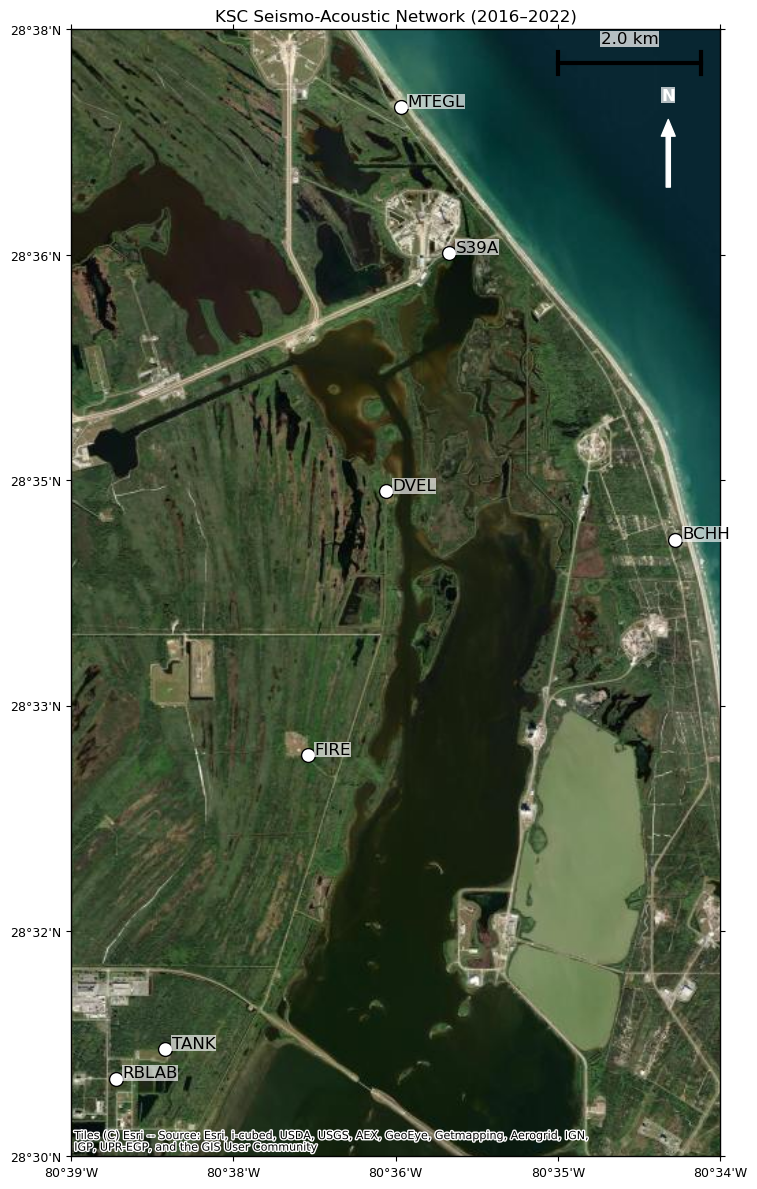

In [4]:
fig, ax, gdf = plot_station_map_tiles(
    excelfile,
    sheet_name="network",
    marker_size=100,
    marker_color="white",
    marker_edgecolor="black",
    label_size=12,
    label_color="black",
    label_dx_frac=0.010,
    label_dy_frac=0.005,
    basemap=cx.providers.Esri.WorldImagery,
    group_clusters=True,
    cluster_frac_x=0.01,
    cluster_frac_y=0.01,
    grouped_name_mode="join",
    add_scalebar=True,
    add_north_arrow=True,
    north_arrow_color="white",
    north_arrow_linewidth=3,
    north_arrow_fontsize=12,
    add_latlon_ticks=True,
    title="KSC Seismo-Acoustic Network (2016–2022)",
)
save_figures(fig, outdir=KSC_DIR, outfilebase="ksc_map_2016_2022_satellite", formats=["png", "pdf"])

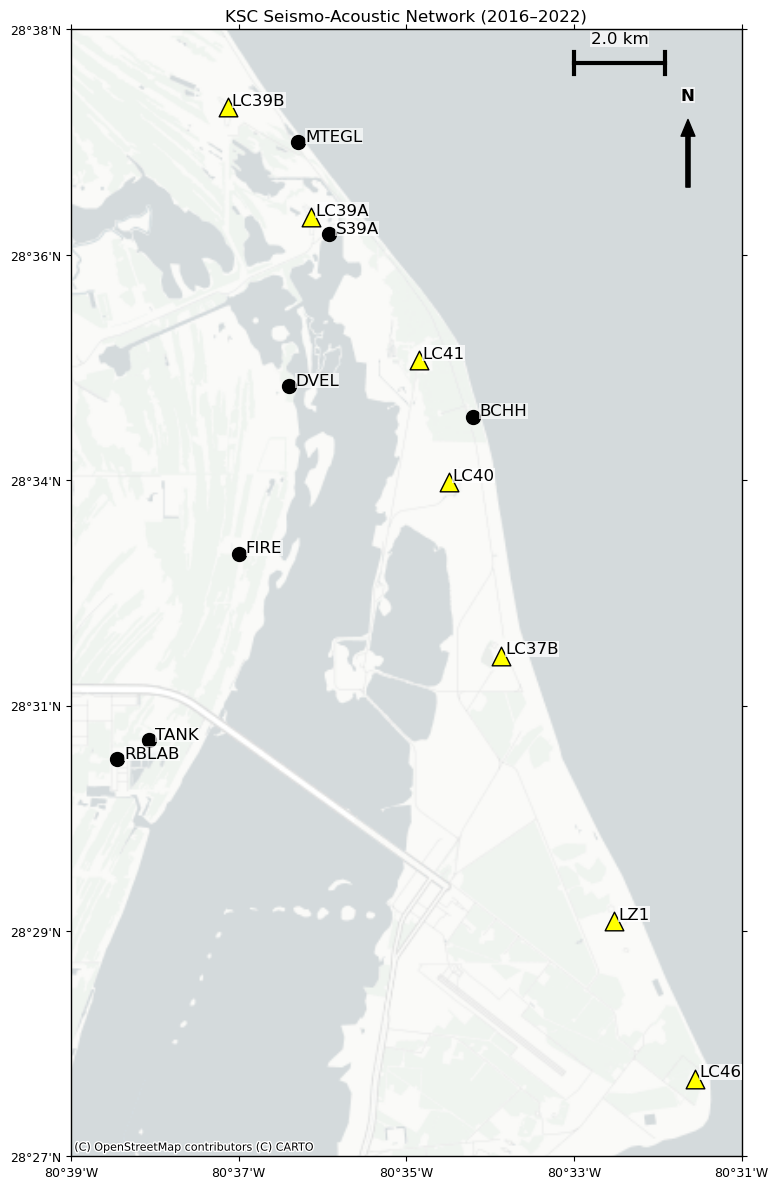

In [16]:

fig, ax, gdf = plot_station_map_tiles(
    excelfile,
    sheet_name="network",
    launchpad_sheet="launchpads",
    marker_size=100,
    marker_color="black",
    marker_edgecolor="black",
    label_size=12,
    label_color="black",
    label_dx_frac=0.010,
    label_dy_frac=0.005,
    basemap=cx.providers.CartoDB.Positron,
    group_clusters=True,
    cluster_frac_x=0.01,
    cluster_frac_y=0.01,
    grouped_name_mode="join",
    add_scalebar=True,
    scalebar_location=(0.75, 0.97),
    scalebar_color="black",
    scalebar_fontsize=12,
    scalebar_linewidth=3,
    add_north_arrow=True,
    north_arrow_color="black",
    north_arrow_linewidth=3,
    north_arrow_fontsize=12,
    add_latlon_ticks=True,
    launchpad_size=180,
    launchpad_color="yellow",
    launchpad_edgecolor="black",
    launchpad_marker="^",
    add_launchpad_labels=True,
    launchpad_label_size=12,
    launchpad_label_color="black",
    title="KSC Seismo-Acoustic Network (2016–2022)",
)
save_figures(fig, outdir=KSC_DIR, outfilebase="ksc_map_2016_2022_simple", formats=["png", "pdf"])


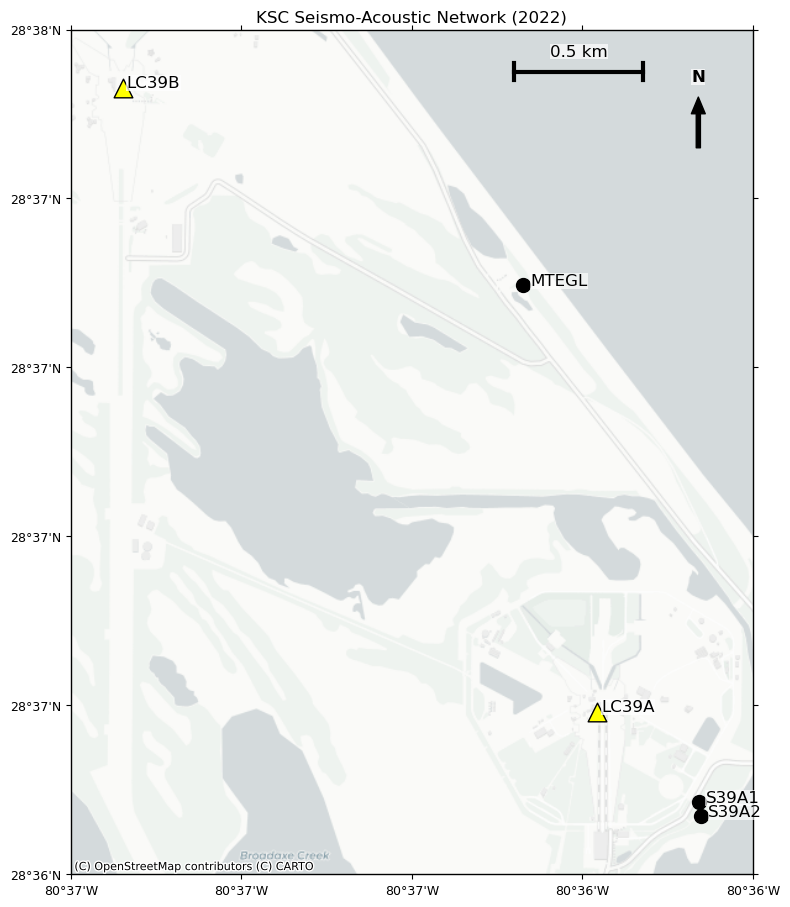

In [13]:
fig, ax, gdf = plot_station_map_tiles(
    excelfile,
    sheet_name="2022",
    launchpad_sheet="launchpads_2022",
    marker_size=100,
    marker_color="black",
    marker_edgecolor="black",
    label_size=12,
    label_color="black",
    label_dx_frac=0.010,
    label_dy_frac=0.005,
    basemap=cx.providers.CartoDB.Positron,
    group_clusters=True,
    cluster_frac_x=0.001,
    cluster_frac_y=0.001,
    grouped_name_mode="join",
    add_scalebar=True,
    scalebar_location=(0.65, 0.95),
    scalebar_color="black",
    scalebar_fontsize=12,
    scalebar_linewidth=3,
    add_north_arrow=True,
    north_arrow_color="black",
    north_arrow_linewidth=3,
    north_arrow_fontsize=12,
    add_latlon_ticks=True,
    launchpad_size=180,
    launchpad_color="yellow",
    launchpad_edgecolor="black",
    launchpad_marker="^",
    add_launchpad_labels=True,
    launchpad_label_size=12,
    launchpad_label_color="black",
    title="KSC Seismo-Acoustic Network (2022)",
)
save_figures(fig, outdir=KSC_DIR, outfilebase="ksc_map_2022_simple", formats=["png", "pdf"])

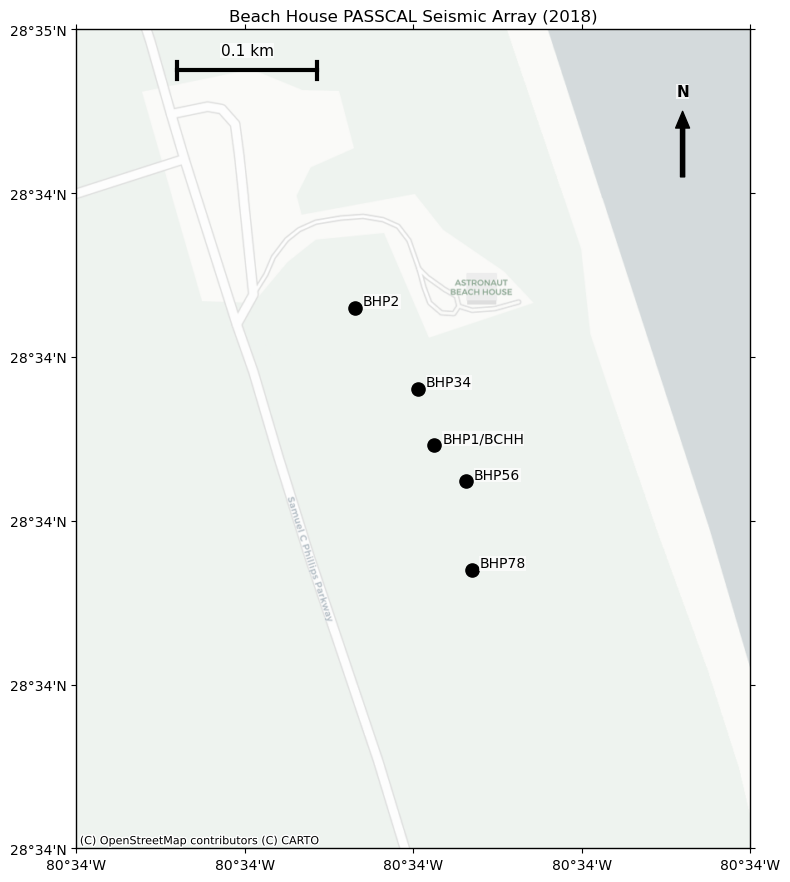

In [14]:
fig, ax, gdf = plot_station_map_tiles(
    excelfile,
    sheet_name="array",
    launchpad_sheet=None,
    pad_fraction=0.20,
    marker_size=90,
    marker_color="black",
    marker_edgecolor="black",
    label_size=10,
    label_color="black",
    label_dx_frac=0.012,
    label_dy_frac=0.008,
    basemap=cx.providers.CartoDB.Positron,
    group_clusters=True,
    add_scalebar=True,
    scalebar_location=(0.15, 0.95),
    scalebar_color="black",
    scalebar_fontsize=11,
    scalebar_linewidth=3,
    add_north_arrow=True,
    north_arrow_color="black",
    north_arrow_linewidth=3,
    north_arrow_fontsize=11,
    north_arrow_pos=(0.90, 0.90),
    north_arrow_length_frac=0.08,
    add_latlon_ticks=True,
    tick_label_size=10,
    title="Beach House PASSCAL Seismic Array (2018)",
)
save_figures(fig, outdir=KSC_DIR, outfilebase="beach_house_array_2018", formats=["png", "pdf"])

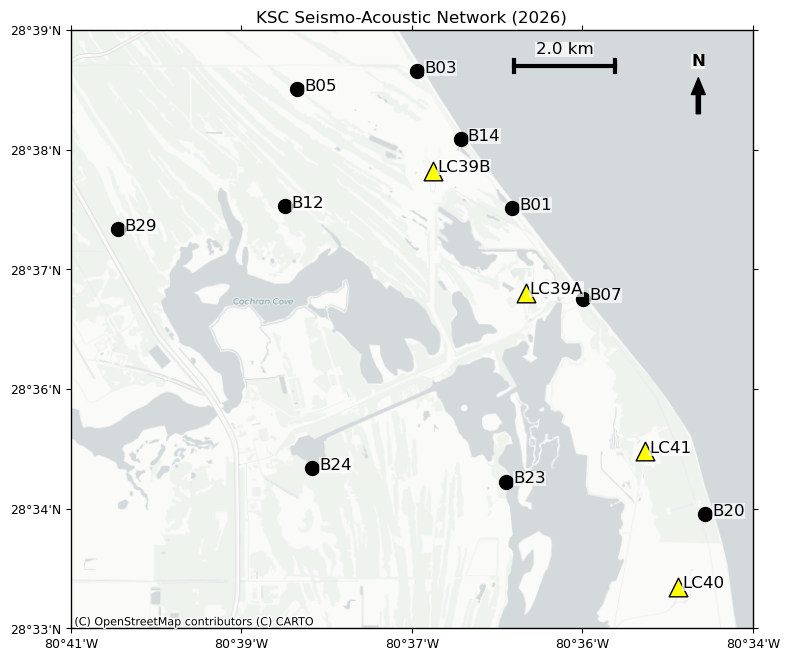

In [15]:

fig, ax, gdf = plot_station_map_tiles(
    excelfile,
    sheet_name="artemis2",
    launchpad_sheet="launchpads_2026",
    marker_size=100,
    marker_color="black",
    marker_edgecolor="black",
    label_size=12,
    label_color="black",
    label_dx_frac=0.010,
    label_dy_frac=0.005,
    basemap=cx.providers.CartoDB.Positron,
    group_clusters=True,
    cluster_frac_x=0.02,
    cluster_frac_y=0.02,
    grouped_name_mode="join",
    add_scalebar=True,
    scalebar_location=(0.65, 0.94),
    scalebar_color="black",
    scalebar_fontsize=12,
    scalebar_linewidth=3,
    add_north_arrow=True,
    north_arrow_color="black",
    north_arrow_linewidth=3,
    north_arrow_fontsize=12,
    add_latlon_ticks=True,
    launchpad_size=180,
    launchpad_color="yellow",
    launchpad_edgecolor="black",
    launchpad_marker="^",
    add_launchpad_labels=True,
    launchpad_label_size=12,
    launchpad_label_color="black",
    title="KSC Seismo-Acoustic Network (2026)",
)
save_figures(fig, outdir=KSC_DIR, outfilebase="ksc_map_2026_simple", formats=["png", "pdf"])


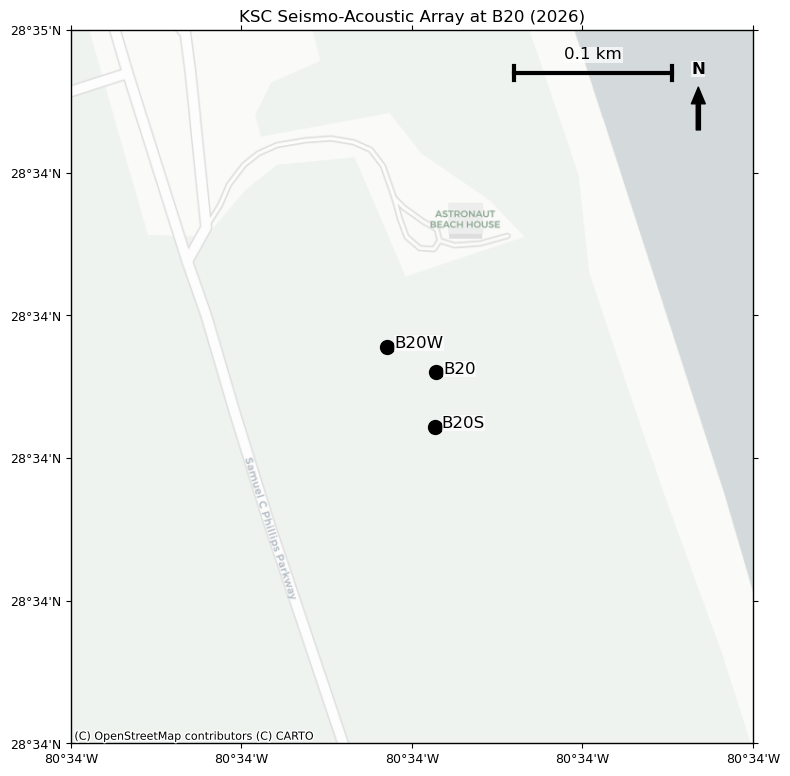

In [9]:

fig, ax, gdf = plot_station_map_tiles(
    excelfile,
    sheet_name="b20_zoom",
    #launchpad_sheet="launchpads_2026",
    marker_size=100,
    marker_color="black",
    marker_edgecolor="black",
    label_size=12,
    label_color="black",
    label_dx_frac=0.010,
    label_dy_frac=0.005,
    basemap=cx.providers.CartoDB.Positron,
    group_clusters=True,
    cluster_frac_x=0.02,
    cluster_frac_y=0.02,
    grouped_name_mode="join",
    add_scalebar=True,
    scalebar_location=(0.65, 0.94),
    scalebar_color="black",
    scalebar_fontsize=12,
    scalebar_linewidth=3,
    add_north_arrow=True,
    north_arrow_color="black",
    north_arrow_linewidth=3,
    north_arrow_fontsize=12,
    add_latlon_ticks=True,
    launchpad_size=180,
    launchpad_color="yellow",
    launchpad_edgecolor="black",
    launchpad_marker="^",
    add_launchpad_labels=True,
    launchpad_label_size=12,
    launchpad_label_color="black",
    title="KSC Seismo-Acoustic Array at B20 (2026)",
)
save_figures(fig, outdir=KSC_DIR, outfilebase="ksc_map_b20_zoom", formats=["png", "pdf"])

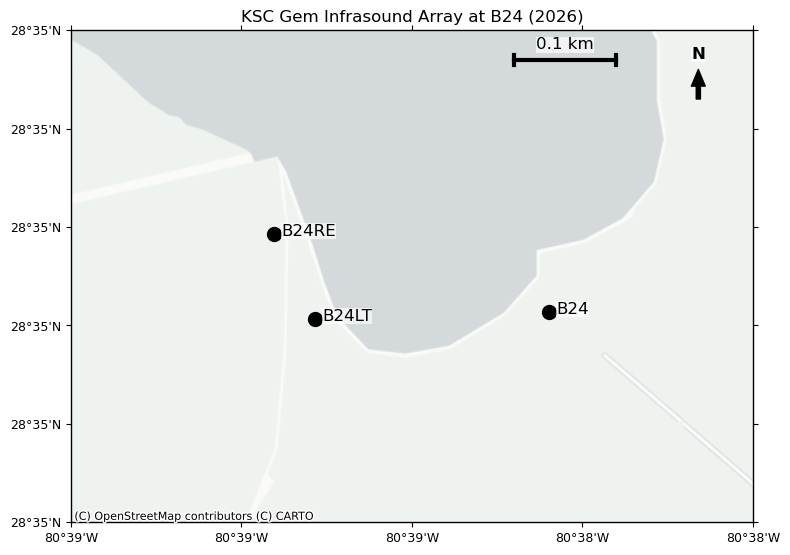

In [10]:

fig, ax, gdf = plot_station_map_tiles(
    excelfile,
    sheet_name="b24_zoom",
    #launchpad_sheet="launchpads_2026",
    marker_size=100,
    marker_color="black",
    marker_edgecolor="black",
    label_size=12,
    label_color="black",
    label_dx_frac=0.010,
    label_dy_frac=0.005,
    basemap=cx.providers.CartoDB.Positron,
    group_clusters=True,
    cluster_frac_x=0.02,
    cluster_frac_y=0.02,
    grouped_name_mode="join",
    add_scalebar=True,
    scalebar_location=(0.65, 0.94),
    scalebar_color="black",
    scalebar_fontsize=12,
    scalebar_linewidth=3,
    add_north_arrow=True,
    north_arrow_color="black",
    north_arrow_linewidth=3,
    north_arrow_fontsize=12,
    add_latlon_ticks=True,
    launchpad_size=180,
    launchpad_color="yellow",
    launchpad_edgecolor="black",
    launchpad_marker="^",
    add_launchpad_labels=True,
    launchpad_label_size=12,
    launchpad_label_color="black",
    title="KSC Gem Infrasound Array at B24 (2026)",
)
save_figures(fig, outdir=KSC_DIR, outfilebase="ksc_map_b24_zoom", formats=["png", "pdf"])